In [ ]:
import pandas as pd

bank_df = pd.read_csv("bank.csv")
bank_df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
object_cols = bank_df.select_dtypes(include='object').columns
for col in object_cols:
    print(bank_df[col].unique())

print(bank_df.isnull().sum())

bank_numeric = bank_df.select_dtypes(exclude='object')
bank_numeric.to_csv("banknumericdata.csv", index=False)

bank_numeric_df = pd.read_csv("banknumericdata.csv")
print(bank_numeric_df.describe())


['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
['married' 'single' 'divorced']
['tertiary' 'secondary' 'unknown' 'primary']
['no' 'yes']
['yes' 'no']
['no' 'yes']
['unknown' 'cellular' 'telephone']
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
['unknown' 'failure' 'other' 'success']
['no' 'yes']
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812  

In [ ]:
med_df = pd.read_csv("medical_student.csv")

for col in med_df.columns:
    if med_df[col].isnull().sum() > 0:
        if med_df[col].dtype in ['float64','int64']:
            med_df[col] = med_df[col].fillna(med_df[col].mean())
        else:
            med_df[col] = med_df[col].fillna(med_df[col].mode()[0])

med_df = med_df.drop_duplicates()
med_df.head()

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.000000,18.000000,Female,161.777924,72.354947,O,27.645835,98.600948,95.0,109.000000,203.0,No,No
1,2.000000,26.021561,Male,152.069157,47.630941,B,23.338869,98.714977,93.0,104.000000,163.0,No,No
2,3.000000,32.000000,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.000000,216.0,Yes,No
3,49974.042078,30.000000,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.000000,141.0,No,Yes
4,5.000000,23.000000,Female,174.947103,46.234173,O,23.338869,98.480008,95.0,114.558033,231.0,No,No


In [ ]:
titanic_df = pd.read_csv("titanic.csv")

subset_df = titanic_df[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']]

first_class_df = subset_df[subset_df['Pclass'] == 1]

print("Fare mean:",first_class_df['Fare'].mean())
print("Fare median:",first_class_df['Fare'].median())
print("Fare max:",first_class_df['Fare'].max())
print("Fare min:",first_class_df['Fare'].min())

titanic_df.head()


Fare mean: 84.1546875
Fare median: 60.287499999999994
Fare max: 512.3292
Fare min: 0.0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
first_class_df = first_class_df.dropna(subset=['Age'])
print(first_class_df['Age'].isnull().sum())
first_class_df.head()


0


,Name,Pclass,Sex,Age,Fare,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,71.2833,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,53.1000,1
6,"McCarthy, Mr. Timothy J",1,male,54.0,51.8625,0
11,"Bonnell, Miss. Elizabeth",1,female,58.0,26.5500,1
23,"Sloper, Mr. William Thompson",1,male,28.0,35.5000,1


In [ ]:
titanic_full = pd.read_csv("titanic.csv")

embarked_dummies = pd.get_dummies(titanic_full['Embarked'], prefix='Embarked')
titanic_full_encoded = pd.concat([titanic_full, embarked_dummies], axis=1)
titanic_full_encoded = titanic_full_encoded.drop(columns=['Embarked'])

print(titanic_full_encoded.head())
titanic_full.head()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0      0         A/5 21171   7.2500   NaN       False       False        True  
1      0          PC 17599  71.2833   C85        True       False       False  
2      0  STON/O2. 3101282   7.9250   NaN       False       False        True  


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


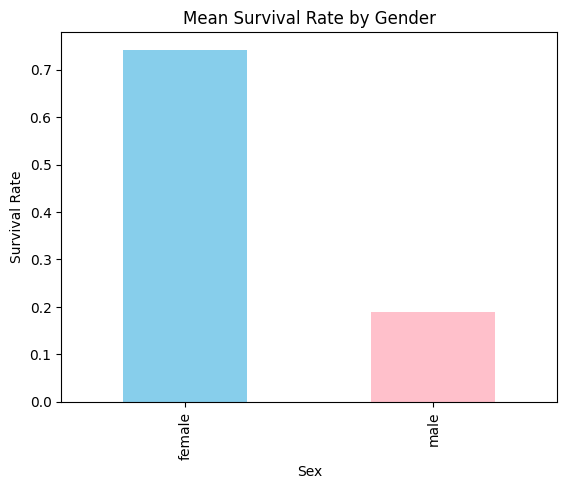

In [ ]:
import matplotlib.pyplot as plt
titanic_full = pd.read_csv("titanic.csv")
mean_survival_gender = titanic_full.groupby('Sex')['Survived'].mean()
print(mean_survival_gender)
mean_survival_gender.plot(kind='bar', color=['skyblue','pink'])
plt.ylabel("Survival Rate")
plt.title("Mean Survival Rate by Gender")
plt.show()

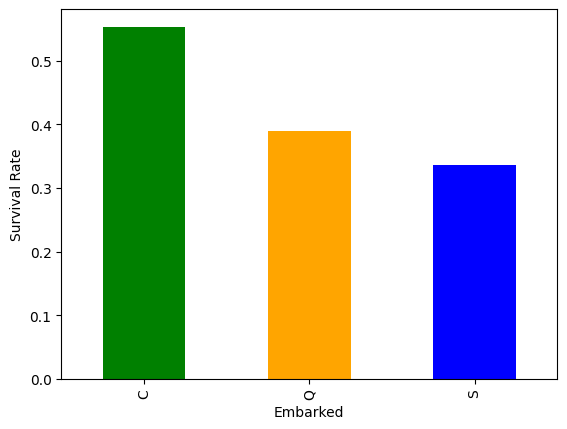

In [ ]:
mean_survival_embarked = titanic_full.groupby('Embarked')['Survived'].mean()
mean_survival_embarked.plot(kind='bar', color=['green','orange','blue'])
plt.ylabel("Survival Rate")
plt.show()


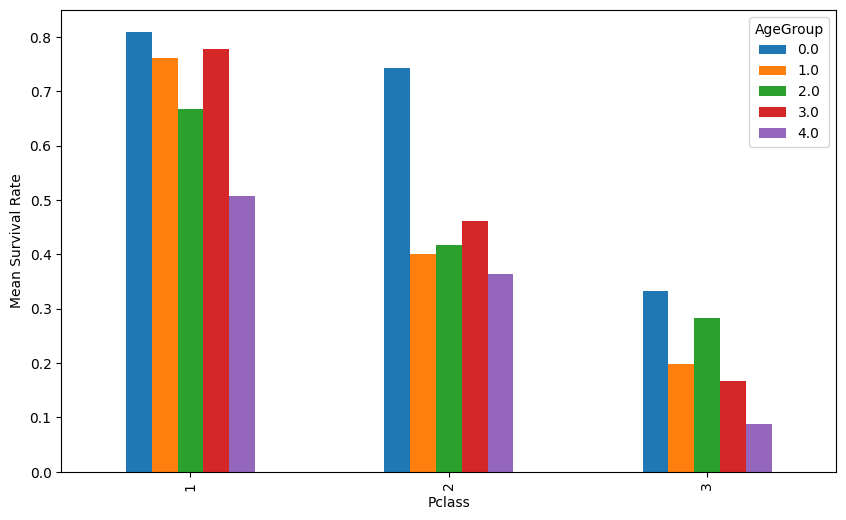

In [ ]:
titanic_full['AgeGroup'] = pd.qcut(titanic_full['Age'], 5, labels=False)
survival_by_age_pclass = titanic_full.groupby(['Pclass','AgeGroup'])['Survived'].mean().unstack()
survival_by_age_pclass.plot(kind='bar', figsize=(10,6))
plt.ylabel("Mean Survival Rate")
plt.show()
